# TITLE: PREDICTIVE MODELLING OF MEDICAL EXPENSES USING LINEAR REGRESSION

# SETTING UP THE ENVIRONMENT
- First we Install the appropriate libraries and packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly as px
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

# Import, Store and Read the Data into a Data Frame called DF

In [2]:
# Use the pd.set_option from pandas to display all columns available in the data.
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv(r"C:\Users\Gifton\Videos\0.0002 DATA ANALYTICS\103_MACHINE_LEARNING\PROJECT_A\medical_insurance_cost_dataset.csv")
df.sample(2)

,customer_id,age,gender,bmi,children,smoker,region,occupation,annual_income_usd,exercise_level,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,insurance_plan,annual_medical_cost_usd
1515,MIC101516,61,Female,20.8,0,No,Northwest,Lawyer,55400,High,0,2,0,14,Basic,9733.85
4519,MIC104520,59,Female,24.9,1,No,Northwest,Teacher,98052,Moderate,2,3,0,8,Basic,14429.33


In [4]:
## Create a copy of the dataset into a Dataframe called df_1
df_1 = df.copy()
df_1.sample(1)

,customer_id,age,gender,bmi,children,smoker,region,occupation,annual_income_usd,exercise_level,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,insurance_plan,annual_medical_cost_usd
6808,MIC106809,26,Male,17.0,2,No,Southwest,Driver,83741,Low,1,4,1,9,Premium,22020.94


## Understanding the Datset
- In this phase we would love to understand how our dataset, the shape, size, if it has any duplicates or missing values.
- Understanding distributions and data patterns will enable us to clean the dataset accordingly before any kind of data analysis begins. 

In [5]:
## Obtain first a quality report:
def data_quality_report(df_1):
    info = {
        'shape': df_1.shape,
        'total record':len(df_1),
        'missing_values':df_1.isnull().sum(),
        'duplicate_rows':df_1.duplicated().sum()
    }
    return info
info = data_quality_report(df_1)
print(info)

{'shape': (7500, 16), 'total record': 7500, 'missing_values': customer_id                     0
age                             0
gender                          0
bmi                             0
children                        0
smoker                          0
region                          0
occupation                      0
annual_income_usd               0
exercise_level                  0
chronic_diseases                0
doctor_visits_per_year          0
hospitalizations_last_year      0
alcohol_consumption_per_week    0
insurance_plan                  0
annual_medical_cost_usd         0
dtype: int64, 'duplicate_rows': np.int64(0)}


## Interpretation of the Results
- The dataset comprises of 7500 Rows and 16 Columns.
- All records are 7500.
- Thted have no missing valuese columns represen
- There are no duplicate rows.

In [6]:
df_1.columns

Index(['customer_id', 'age', 'gender', 'bmi', 'children', 'smoker', 'region',
       'occupation', 'annual_income_usd', 'exercise_level', 'chronic_diseases',
       'doctor_visits_per_year', 'hospitalizations_last_year',
       'alcohol_consumption_per_week', 'insurance_plan',
       'annual_medical_cost_usd'],
      dtype='object')

In [7]:
## What are the various data types representing the datasets inside the columns?
df_1.dtypes

customer_id                      object
age                               int64
gender                           object
bmi                             float64
children                          int64
smoker                           object
region                           object
occupation                       object
annual_income_usd                 int64
exercise_level                   object
chronic_diseases                  int64
doctor_visits_per_year            int64
hospitalizations_last_year        int64
alcohol_consumption_per_week      int64
insurance_plan                   object
annual_medical_cost_usd         float64
dtype: object

In [8]:
numerical_cols =df_1.select_dtypes(include=['int64', 'float64'])
numerical_cols.sample(2)

,age,bmi,children,annual_income_usd,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,annual_medical_cost_usd
3790,28,30.8,1,67705,0,1,0,8,14271.09
5072,52,26.9,2,92652,1,6,0,10,12892.02


In [9]:
categorical_cols = df_1.select_dtypes(include=['object'])
categorical_cols.sample(2)

,customer_id,gender,smoker,region,occupation,exercise_level,insurance_plan
457,MIC100458,Male,No,Northwest,Driver,Moderate,Gold
2490,MIC102491,Female,Yes,Southwest,Doctor,Moderate,Standard


## Computing Summary Statistics
- To understand measure of central tendencies and spread of the dataset, we Compute summary statistics to give an idea about the dataset.

In [10]:
## Compute Sample Statistics to understand how the various types of data re distributed
numerical_stats = numerical_cols.describe()
numerical_stats

,age,bmi,children,annual_income_usd,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,annual_medical_cost_usd
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,41.332400,28.054173,1.493867,65344.240000,0.704533,4.713067,0.343733,6.975467,17912.526807
std,13.913264,4.932231,1.210409,24728.459461,0.847110,2.290554,0.561209,4.298681,7574.460081
min,18.000000,16.000000,0.000000,18000.000000,0.000000,0.000000,0.000000,0.000000,1500.000000
25%,29.000000,24.600000,1.000000,47987.500000,0.000000,3.000000,0.000000,3.000000,12385.620000
50%,41.000000,28.000000,1.000000,65041.500000,1.000000,4.000000,0.000000,7.000000,16361.925000
75%,53.000000,31.500000,2.000000,82228.000000,1.000000,6.000000,1.000000,11.000000,22555.107500
max,65.000000,45.000000,5.000000,176977.000000,5.000000,15.000000,3.000000,14.000000,49332.680000


In [11]:
categorical_stats = categorical_cols.describe()
categorical_stats

,customer_id,gender,smoker,region,occupation,exercise_level,insurance_plan
count,7500,7500,7500,7500,7500,7500,7500
unique,7500,2,2,5,11,3,4
top,MIC100001,Male,No,Northwest,Technician,Moderate,Standard
freq,1,3767,6029,1562,705,3705,3007


## Understanding Distribution Patterns For Each and Every Column
- Important to understand how the columns in the dataset are distributed. If either is Skewed so much, we will need to transform them before data modelling begins.

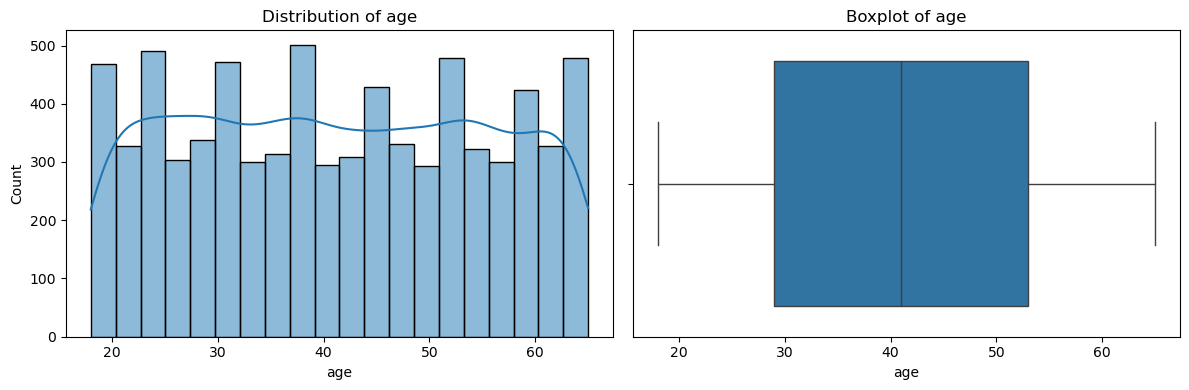

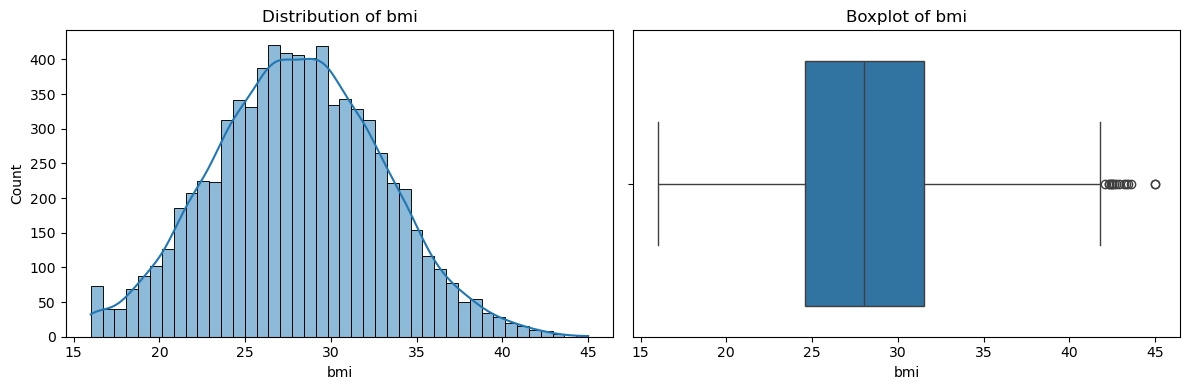

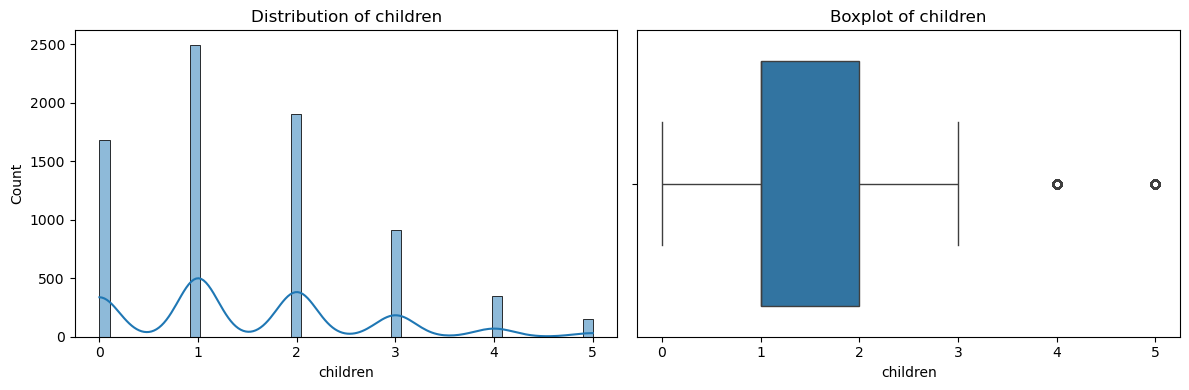

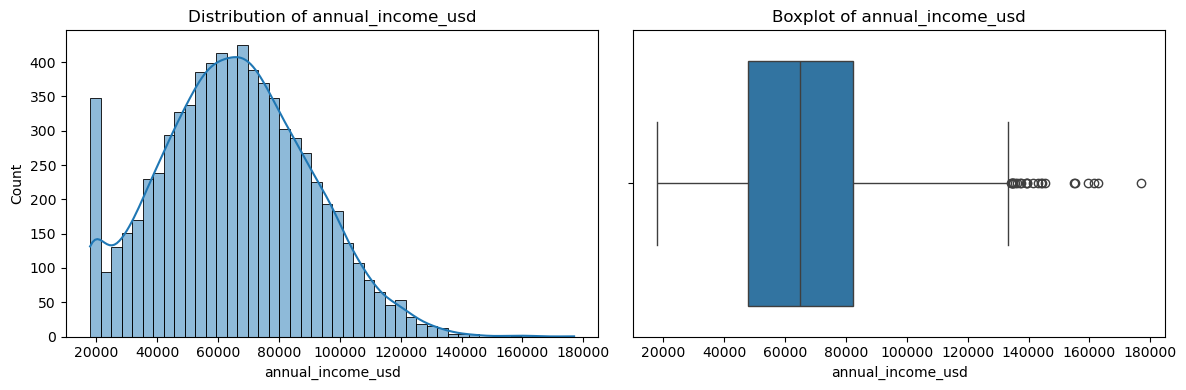

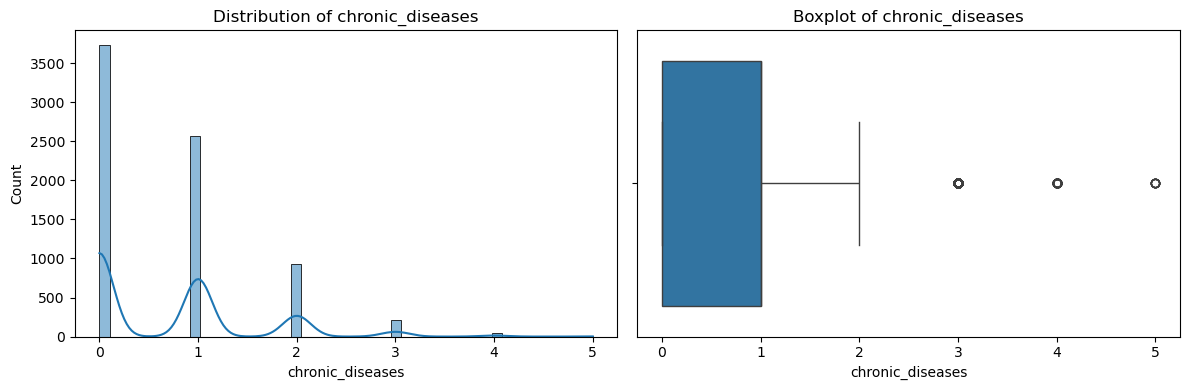

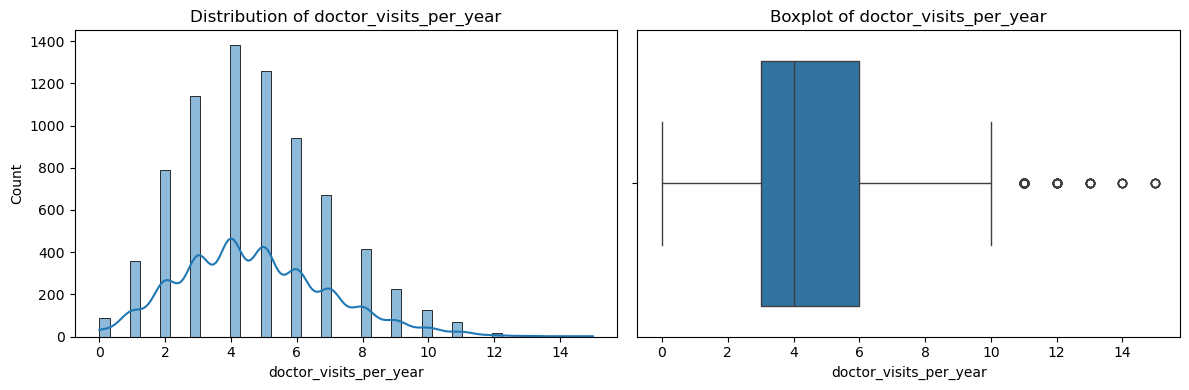

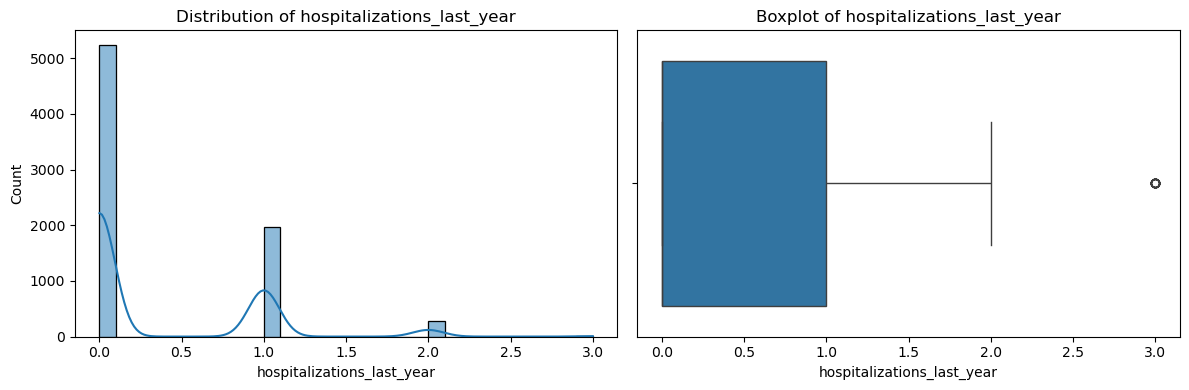

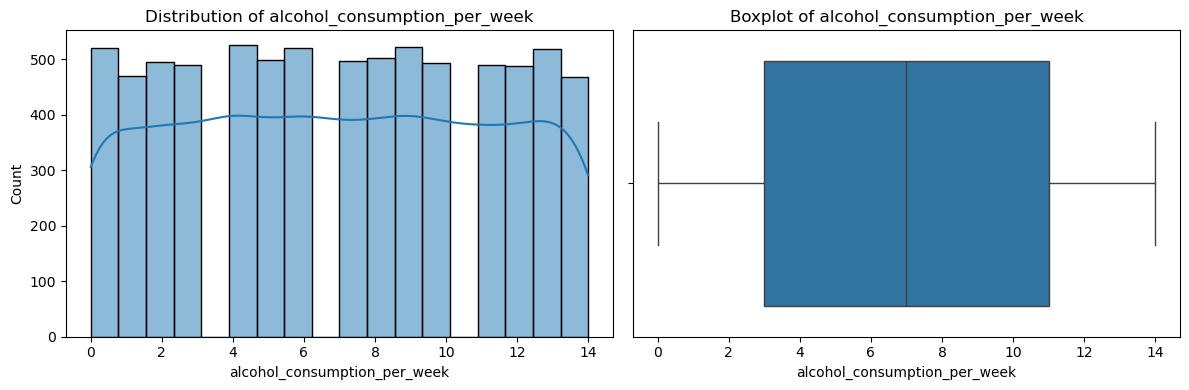

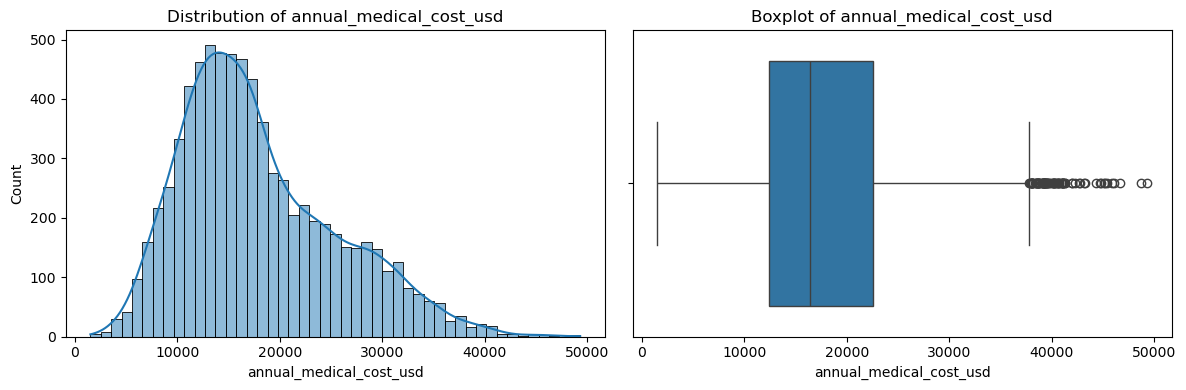

In [12]:
## How are each and every column Distributed in the Numerical VS Categorical Columns?
# For Numerical_cols:
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Histogram with KDE
    sns.histplot(df_1[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    # Boxplot to spot outliers
    sns.boxplot(x=df_1[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

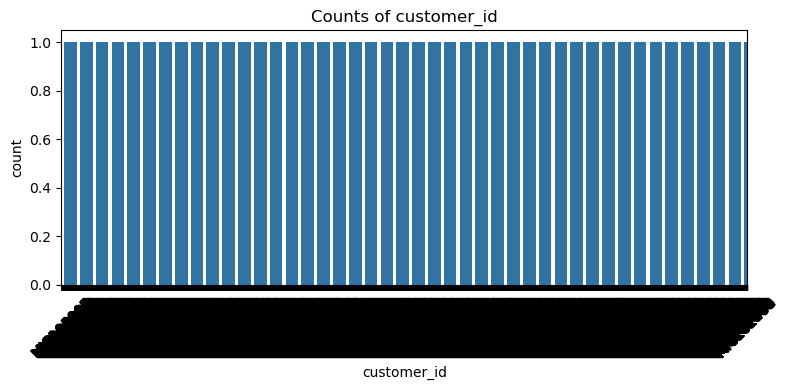

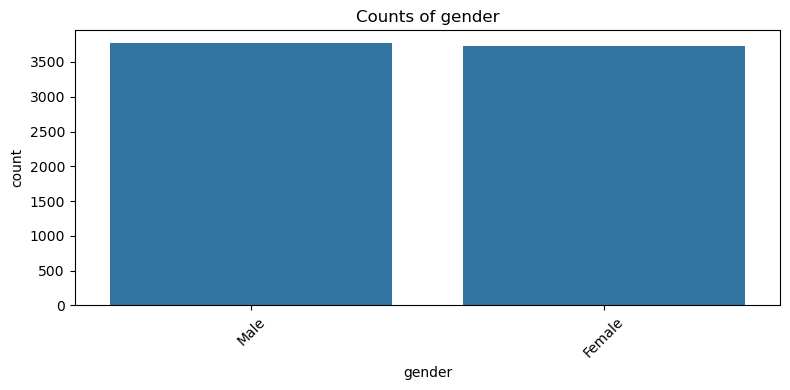

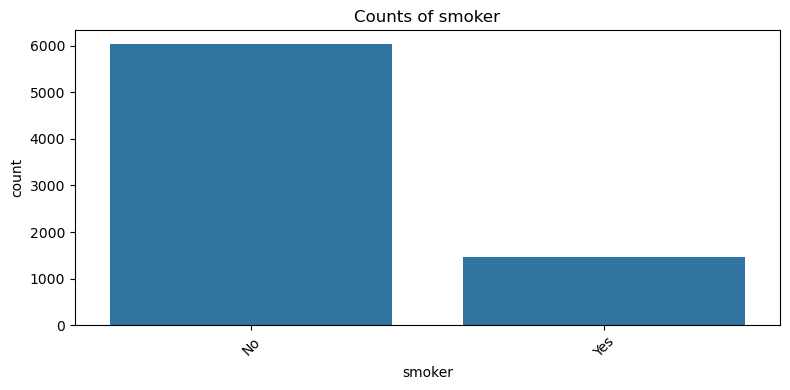

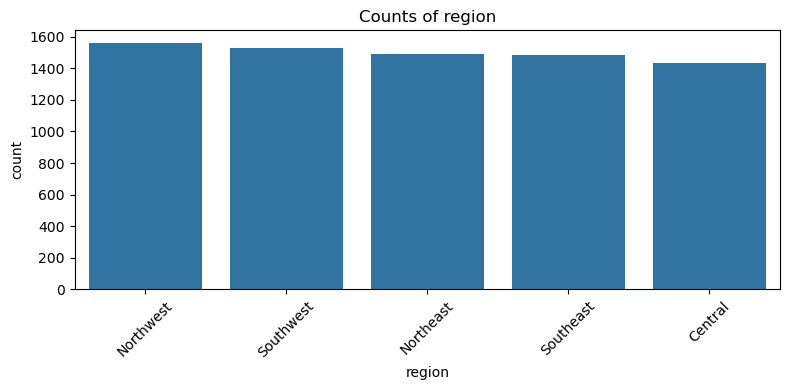

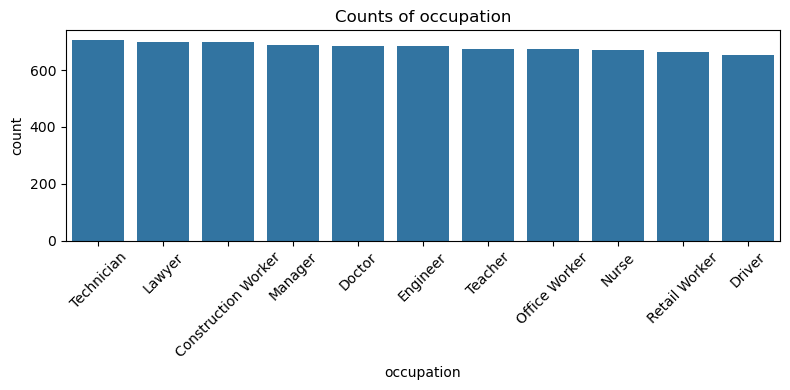

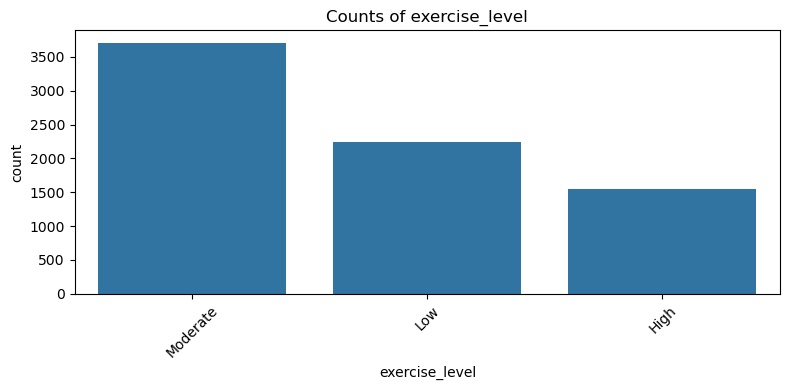

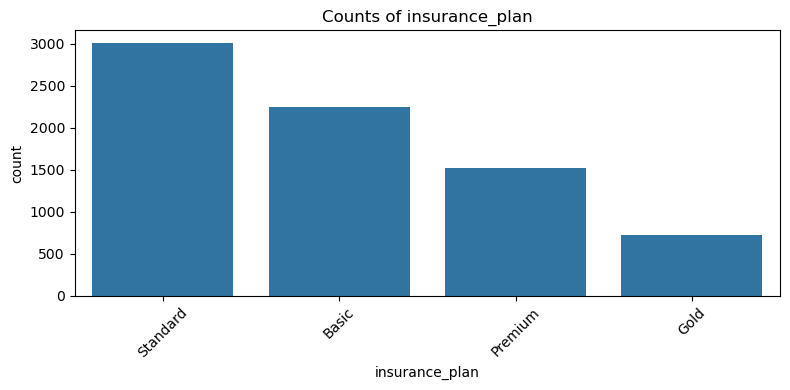

In [13]:
## For Categorical_Columns:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_1, x=col, order=df[col].value_counts().index)
    plt.title(f'Counts of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## How are some of the Numerical and Categorical Variables compare to the Response variable in  this case "The Annual Medical Cost in USD"
- Since we are modelling Annual Medical Cost against select variables, it is important to estimate the relationships between each of the Predictor variable and the Predicted variable in our case Annual Medical Cost USD

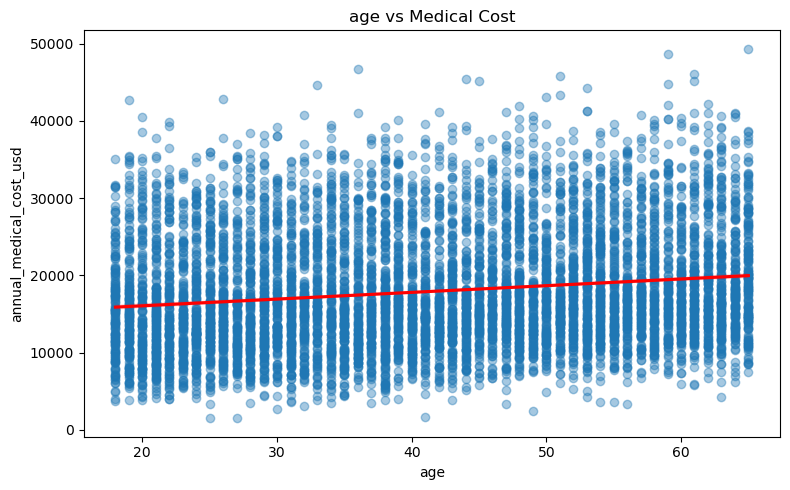

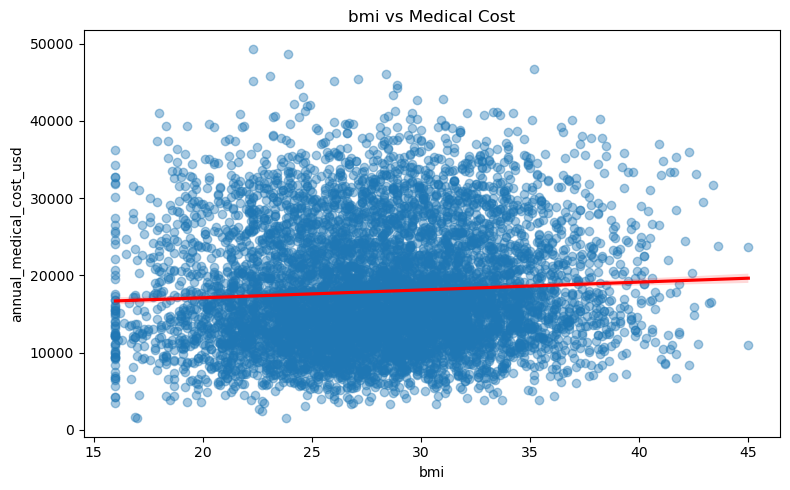

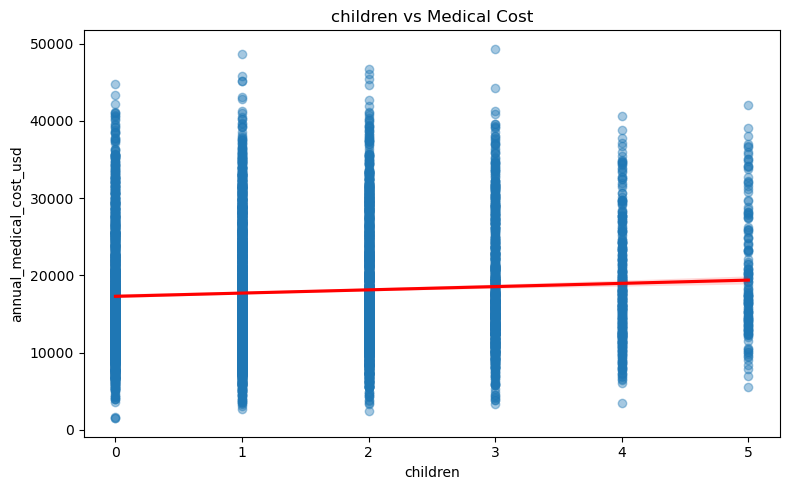

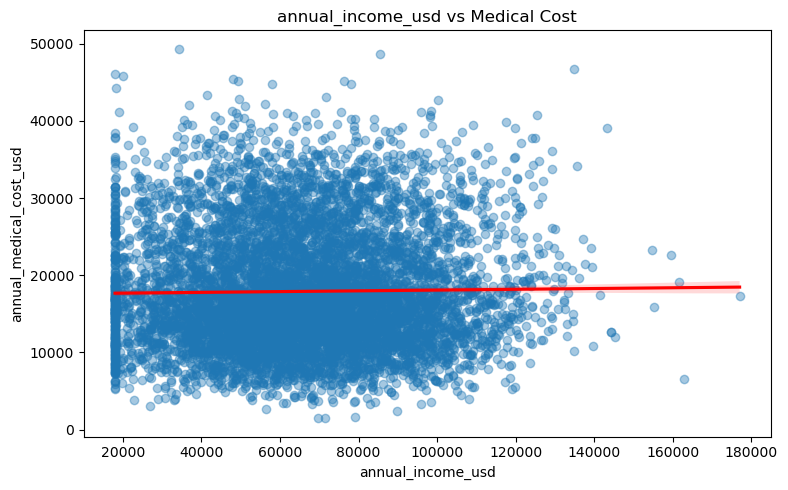

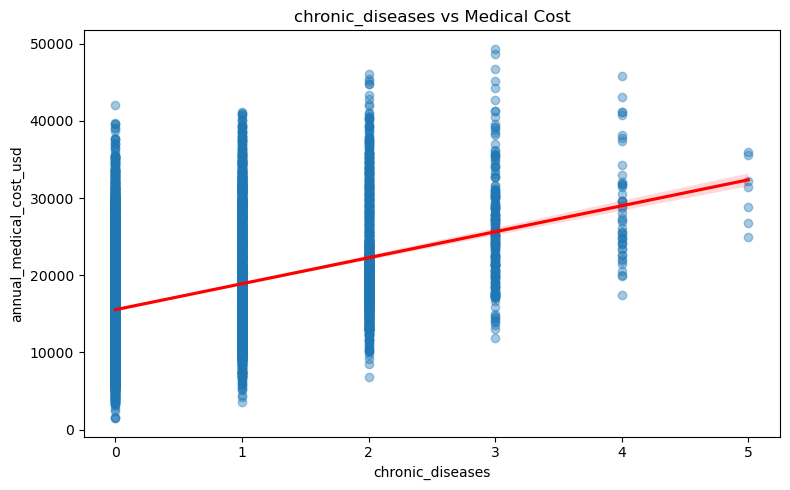

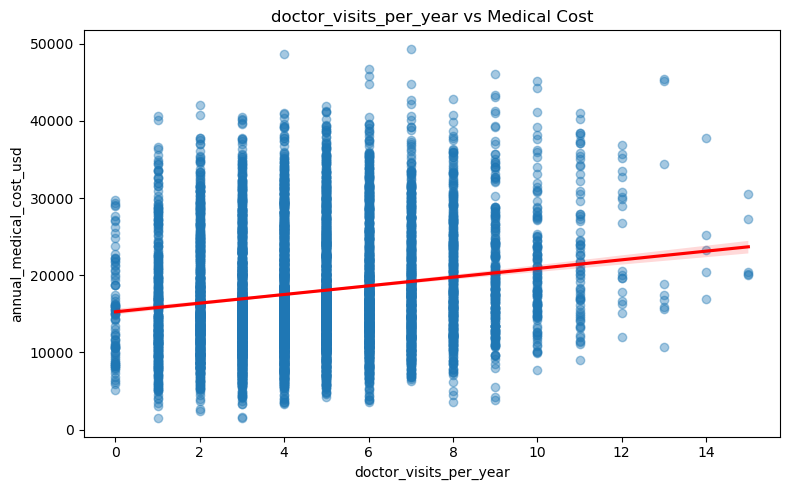

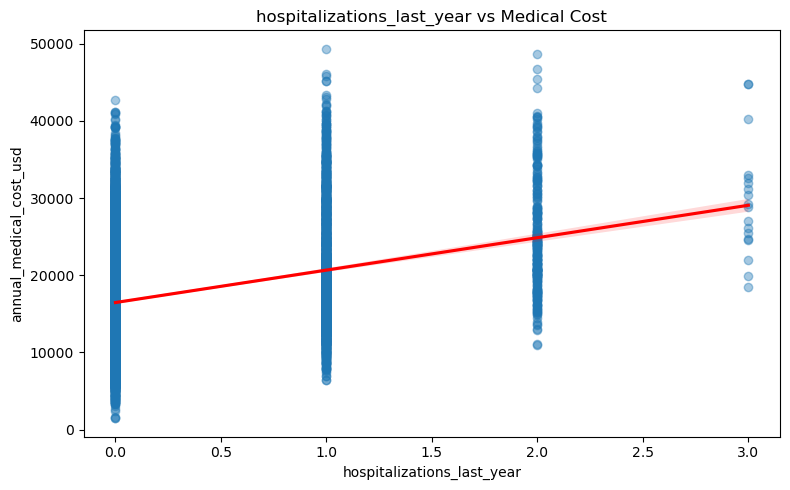

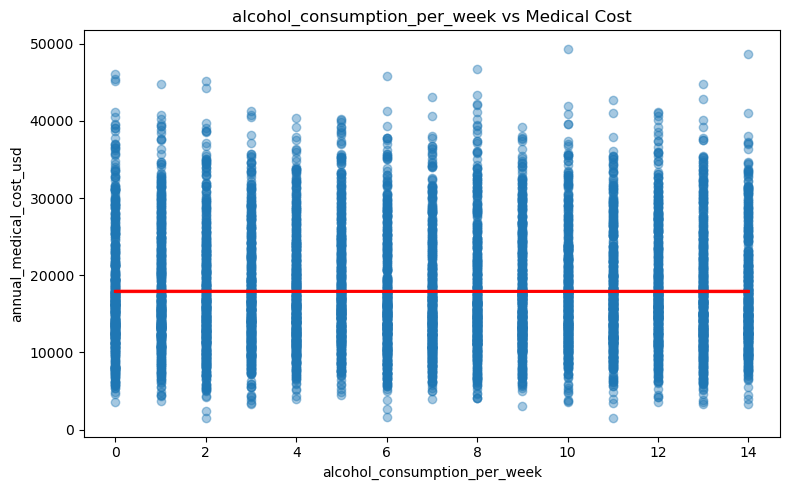

In [14]:
for col in numerical_cols:
    if col != 'annual_medical_cost_usd':
        plt.figure(figsize=(8,5))
        sns.regplot(data=df_1, x=col, y='annual_medical_cost_usd', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
        plt.title(f'{col} vs Medical Cost')
        plt.tight_layout()
        plt.show

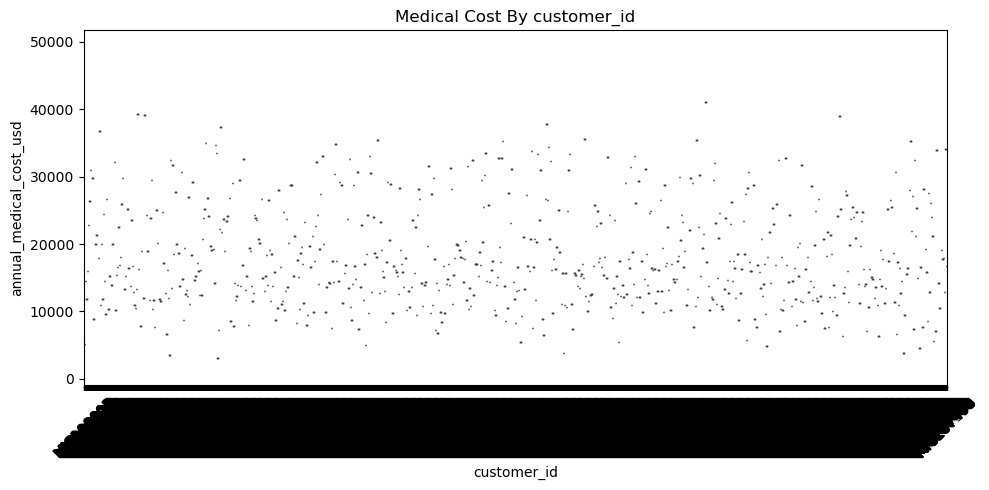

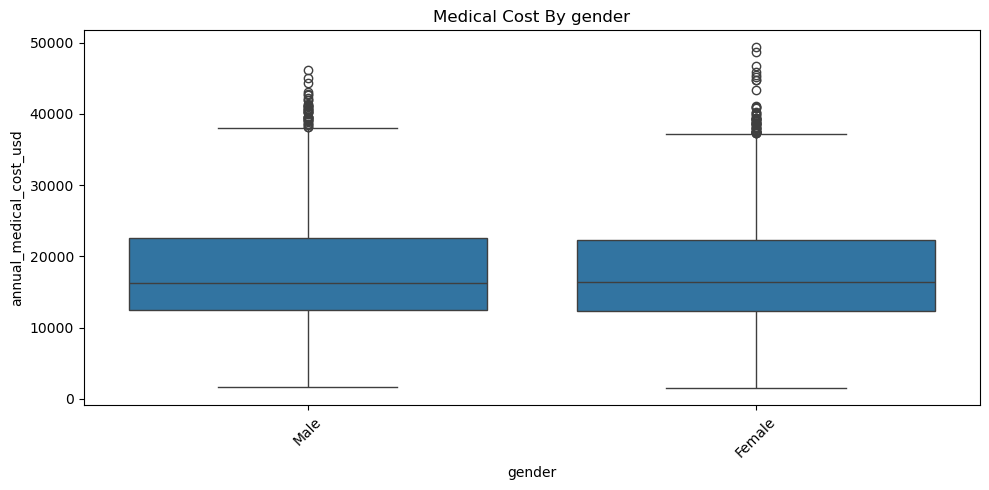

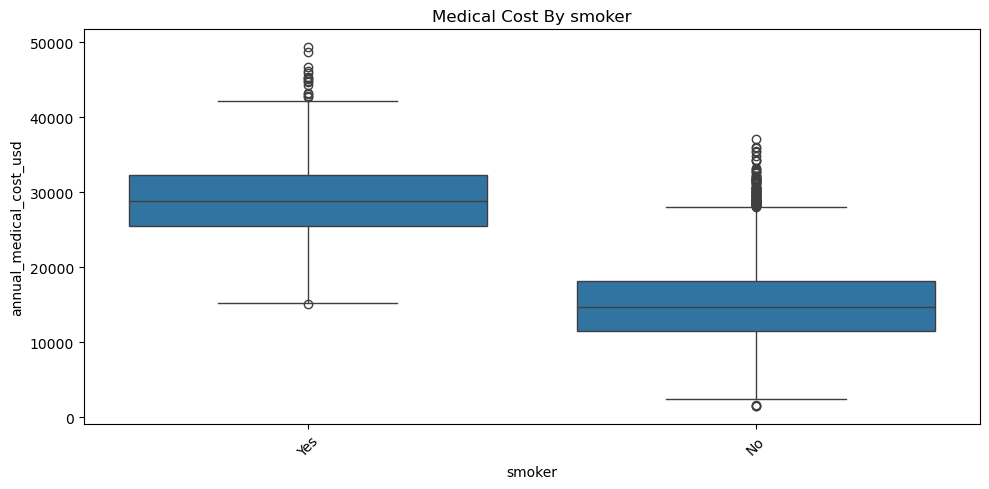

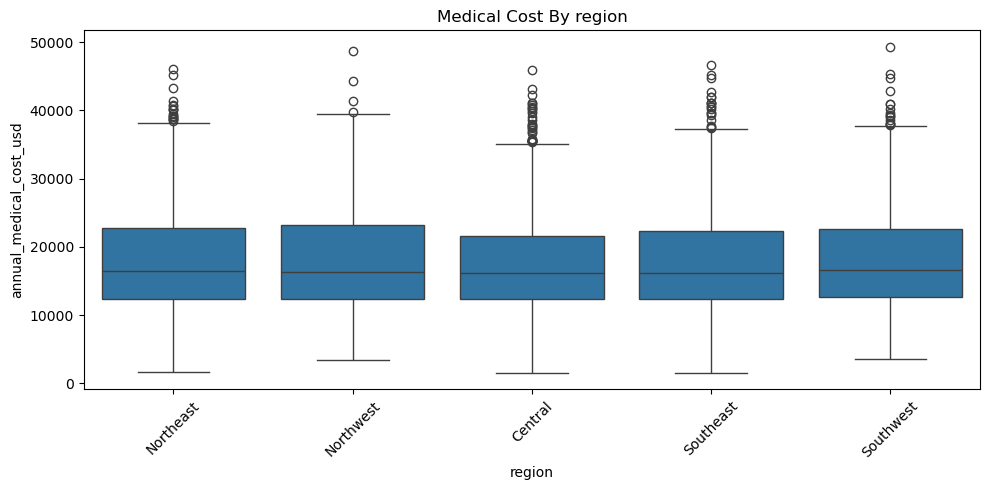

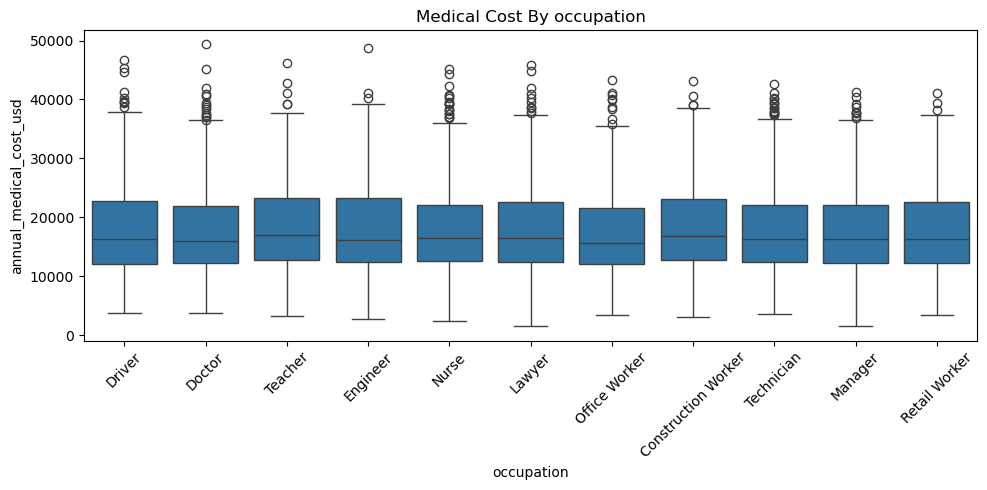

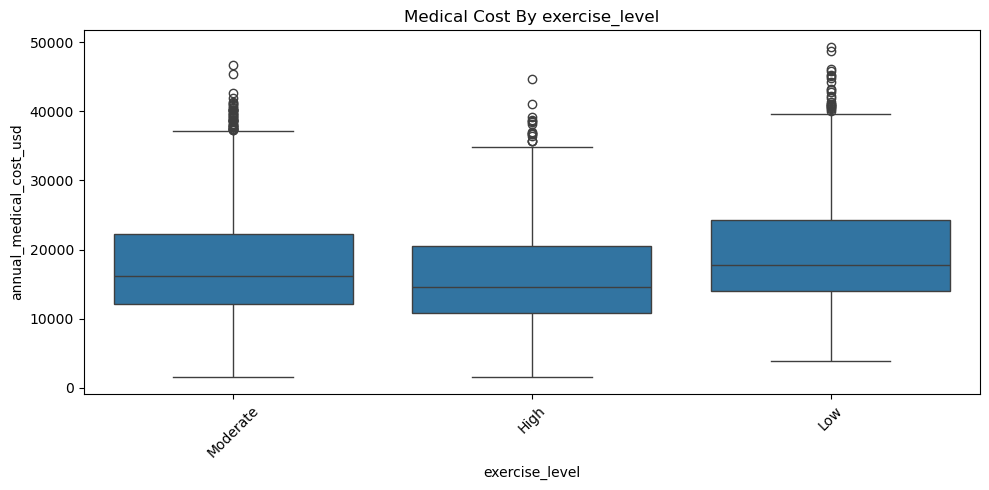

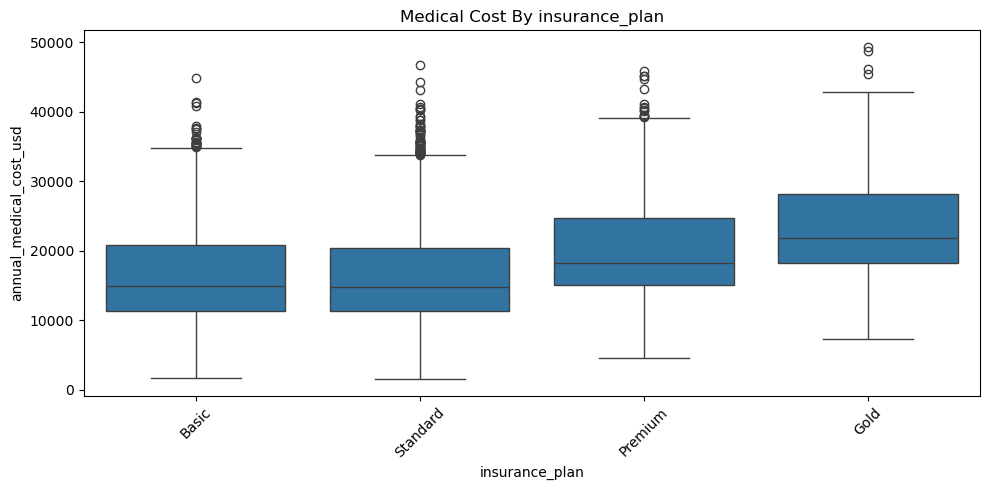

In [15]:
## For Categorical Variables and how the affect the Annual Medical Cost Usd:
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df_1, x=col, y='annual_medical_cost_usd')
    plt.title(f"Medical Cost By {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Correlation Explorations:
- We would love to explore which of the predictor variables is closely associated to the target variable "Annual Medical Cost USD"
- Correlation works primarily ONLY for Numerical Data. Categoriacal variable cases will have to be converted first before relationships are explored.

In [16]:
# Define target and features
target = 'annual_medical_cost_usd'
features = ['age', 'bmi', 'children', 'annual_income_usd', 'chronic_diseases',
       'doctor_visits_per_year', 'hospitalizations_last_year',
       'alcohol_consumption_per_week']

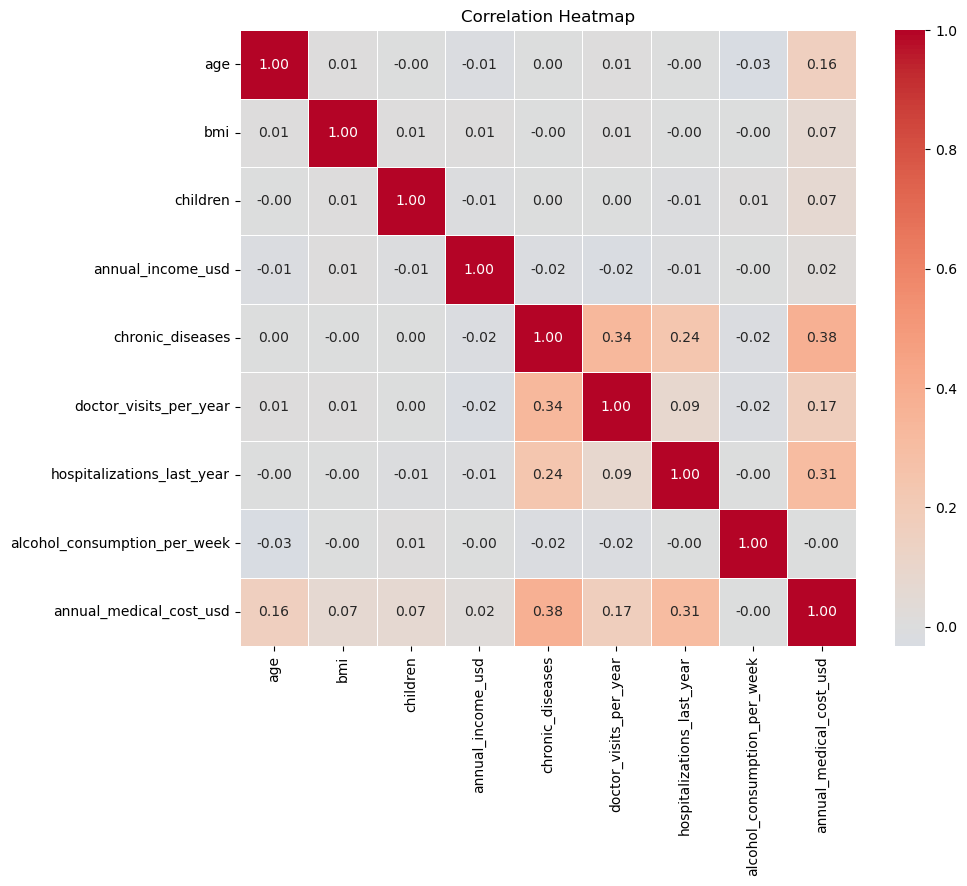

In [17]:
# Calculate correlation
corr_matrix = df_1[features + [target]].corr()
    
# Plot heatmap
plt.figure(figsize=(10, 8))
    
# Full heatmap
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm', center=0, fmt='.2f',linewidths=0.5,square=True)
plt.title('Correlation Heatmap')
plt.show()

# BULDING OF A MULTIPLE FEATURE REGRESSION MODEL:
- We start by defining the Target and predictor variables from the dataframe
- The Target Variable: Annual Medical Cost USD
- The Predictor variables includes all numerical columns:'age, bmi, children, annual_income_usd, chronic_diseases, doctor_visits_per_year,hospitalizations_last_year ,alcohol_consumption_per_week.

- We start by Installing Scikit Learn which is necessary for Machine Learning.

In [18]:
!pip install scikit-learn --quiet

Then we import the necessary library modules to be used. In our case:
- Linear Regression
- TrainTest Split

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [20]:
## Defining the x and y variables:
x = df_1[['age','chronic_diseases','doctor_visits_per_year', 'hospitalizations_last_year']]
y = df_1['annual_medical_cost_usd']

In [21]:
## Break down further our dataset into Training Dataset and the Hold out sample:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [22]:
## Construct the Model
ols_formula = 'annual_medical_cost_usd ~ age + chronic_diseases + doctor_visits_per_year + hospitalizations_last_year'

In [23]:
## We then import the OLS Function:
from statsmodels.formula.api import ols

In [24]:
## Define the OLS Data Frame:
ols_data = pd.concat([x_train, y_train], axis=1)


In [25]:
## Create the OLS oBJECT AND FIT THE mODEL:
OLS = ols(formula = ols_formula, data = ols_data)
model = OLS.fit()

In [26]:
## Obtain Summary Results:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     annual_medical_cost_usd   R-squared:                       0.230
Model:                                 OLS   Adj. R-squared:                  0.229
Method:                      Least Squares   F-statistic:                     391.6
Date:                     Fri, 24 Jul 2026   Prob (F-statistic):          1.36e-295
Time:                             09:39:09   Log-Likelihood:                -53700.
No. Observations:                     5250   AIC:                         1.074e+05
Df Residuals:                         5245   BIC:                         1.074e+05
Df Model:                                4                                         
Covariance Type:                 nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   1.056e+04    347.967     30.337      0.000    9873.962    1.12e+04
age                           86.4650      6.670     12.963      0.000      73.388      99.542
chronic_diseases            2779.2822    117.981     23.557      0.000    2547.990    3010.574
doctor_visits_per_year       168.4971     42.453      3.969      0.000      85.271     251.724
hospitalizations_last_year  3241.7752    168.839     19.200      0.000    2910.781    3572.769
==============================================================================
Omnibus:                      577.620   Durbin-Watson:                   2.055
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              787.723
Skew:                           0.945   Prob(JB):                    8.87e-172
Kurtosis:                       3.164   Cond. No.                         166.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Results Interpretation:
- Based on the four predictor variables: Age, Chronic disease, Doctors Visit and Hospitalizations last year, the R-Squared value is at  0.230 approximately 23%. Implying that only 23 of the Annual Medical Cost is explain by the four predictor variables.
- To improve the Model RSquared Accuracy, we'll need to add more feature variables to the model.

## What about Categorical Columns?
First they need to be transformed into Numeric Values

In [27]:
categorical_cols.columns

Index(['customer_id', 'gender', 'smoker', 'region', 'occupation',
       'exercise_level', 'insurance_plan'],
      dtype='object')

In [28]:
df_1['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [29]:
#For Gender:
gender_encoded = {
    'Female':0,
    'Male':1
}
df_1['gender_encoded'] =df_1['gender'].map(gender_encoded)
    

In [30]:
## For Smoker:
smoker_encoded = {
    'No':0,
    'Yes':1
}
df_1['smoker_encoded'] =df_1['smoker'].map(smoker_encoded)

In [31]:
## For exercise Level:
exercise_encoded = {
    'Low':0,
    'Moderate':1,
    'High':2
}
df_1['exercise_encoded'] =df_1['exercise_level'].map(exercise_encoded)

In [32]:
## For Insurance Plan:
insurance_encoded = {
    'Basic':0,
    'Standard':1,
    'Premium':2,
    'Gold':3
}
df_1['insurance_encoded'] = df_1['insurance_plan'].map(insurance_encoded)

In [33]:
## To view if our new columns have been successfully added:
df_1.sample(2)

,customer_id,age,gender,bmi,children,smoker,region,occupation,annual_income_usd,exercise_level,chronic_diseases,doctor_visits_per_year,hospitalizations_last_year,alcohol_consumption_per_week,insurance_plan,annual_medical_cost_usd,gender_encoded,smoker_encoded,exercise_encoded,insurance_encoded
4373,MIC104374,26,Female,31.1,2,No,Northeast,Manager,63540,Moderate,0,3,1,2,Standard,6386.03,0,0,1,1
46,MIC100047,49,Male,39.3,2,No,Northwest,Office Worker,50660,Moderate,1,4,0,2,Standard,16991.06,1,0,1,1


In [34]:
df_1.columns

Index(['customer_id', 'age', 'gender', 'bmi', 'children', 'smoker', 'region',
       'occupation', 'annual_income_usd', 'exercise_level', 'chronic_diseases',
       'doctor_visits_per_year', 'hospitalizations_last_year',
       'alcohol_consumption_per_week', 'insurance_plan',
       'annual_medical_cost_usd', 'gender_encoded', 'smoker_encoded',
       'exercise_encoded', 'insurance_encoded'],
      dtype='object')

## Correlation:
- We would love to explore the relationships between the target variable Annual Medical Cost and the Newly transformed Categorical variables

In [35]:
## Define Correlations for the Newly encoded Categorical Variables:
target_var = 'annual_medical_cost_usd'
predictor_var = ['gender_encoded', 'smoker_encoded',
       'exercise_encoded', 'insurance_encoded']

In [36]:
## Calculate the Correlation Matrix:
corr_matrix = df_1[predictor_var+[target_var]].corr()

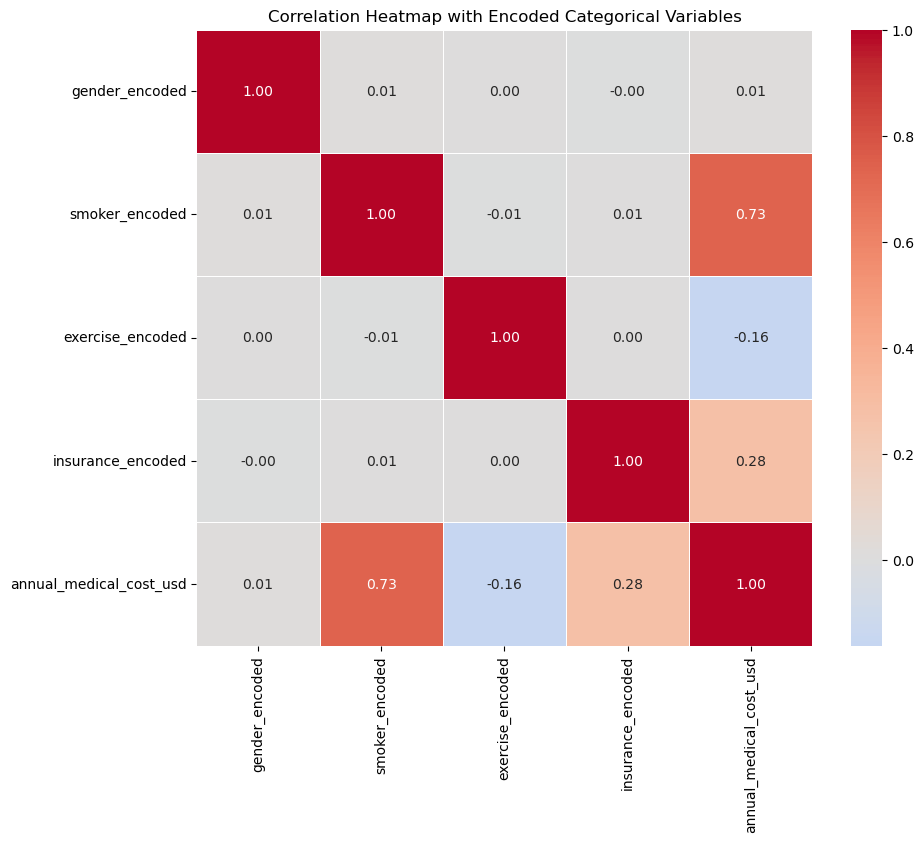

In [37]:
## Plot A Heatmap to Visualize the data:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidth=0.5, square=True)
plt.title('Correlation Heatmap with Encoded Categorical Variables')
plt.show()

## Improving on the Model:
- Having defined the new features by transforming the Categorical features, we'd like to improve the Model by adding Categorical numeric features with the strong correlation to the Target variable.

In [38]:
# Include smoker and Insurance encoded variable to the model:
x = df_1['annual_medical_cost_usd']
y = df_1[['age', 'chronic_diseases', 'doctor_visits_per_year', 'hospitalizations_last_year', 'smoker_encoded','insurance_encoded']]

In [39]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [40]:
ols_formula = 'annual_medical_cost_usd ~ age+chronic_diseases+doctor_visits_per_year+hospitalizations_last_year+smoker_encoded + insurance_encoded'

In [41]:
ols_data=pd.concat([x_train,y_train],axis=1)

In [42]:
OLS = ols(formula = ols_formula, data = ols_data)
model = OLS.fit()

In [43]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     annual_medical_cost_usd   R-squared:                       0.838
Model:                                 OLS   Adj. R-squared:                  0.838
Method:                      Least Squares   F-statistic:                     4525.
Date:                     Fri, 24 Jul 2026   Prob (F-statistic):               0.00
Time:                             09:48:56   Log-Likelihood:                -49605.
No. Observations:                     5250   AIC:                         9.922e+04
Df Residuals:                         5243   BIC:                         9.927e+04
Df Model:                                6                                         
Covariance Type:                 nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   5466.2414    168.070     32.524      0.000    5136.755    5795.728
age                           85.7641      3.059     28.039      0.000      79.768      91.761
chronic_diseases            2748.7585     54.105     50.804      0.000    2642.690    2854.827
doctor_visits_per_year       160.6472     19.467      8.252      0.000     122.483     198.811
hospitalizations_last_year  3235.1627     77.422     41.786      0.000    3083.384    3386.941
smoker_encoded              1.401e+04    106.684    131.339      0.000    1.38e+04    1.42e+04
insurance_encoded           2185.3214     45.223     48.323      0.000    2096.665    2273.977
==============================================================================
Omnibus:                        7.541   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.023   Jarque-Bera (JB):                6.783
Skew:                           0.039   Prob(JB):                       0.0337
Kurtosis:                       2.842   Cond. No.                         176.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Result Interpretation:
- The Model accuracy has improved to 0.838 approximately 84% variation of the Target variables explained by the Predictor Variables.
- The Coefficient values of each of the Variable is 0.000 less than P-Value of 0.005 implying they are all Significant at predicting the Target variable ['annual medical cost in USD']